# Image Segmentation

> **Implementation Notes**
>
> This notebook implements **U-Net** completely from scratch using TensorFlow/Keras to demonstrate the encoder–decoder architecture and skip connections described in the original paper.
>
> The **U-Net++** implementation in this notebook is a **simplified educational implementation** inspired by the original architecture. It demonstrates the core idea of **nested skip connections** between the encoder and decoder, but it **does not fully reproduce the original research model**. Specifically, this implementation omits:
>
> - the complete dense skip connection topology across all intermediate nodes,
> - **deep supervision** with multiple output heads,
> - the full decoder grid (e.g., all \(X <sup>{i, j}</sup> \) nodes described in the paper),
> - optional pruning modes used for inference optimization, and
> - the experimental training configuration and evaluation protocol reported in the original paper.
>
> The implementation is intended to help students understand the fundamental architectural concepts while keeping the code concise and easy to follow..
>
> For **DeepLabV3+**, this notebook uses the **official pretrained implementation provided through KerasHub**, rather than reimplementing the architecture from scratch.
>
> For **Mask R-CNN**, this notebook uses the **official pretrained implementation provided by TorchVision**, trained on the COCO dataset, instead of implementing the complete detection and segmentation framework manually.
>
> **Original Research Papers**
>
> - **U-Net:** https://arxiv.org/abs/1505.04597
> - **U-Net++:** https://arxiv.org/abs/1807.10165
> - **DeepLabV3+:** https://arxiv.org/abs/1802.02611
> - **Mask R-CNN:** https://arxiv.org/abs/1703.06870
>
> The goal of this notebook is to get familiar with modern image segmentation architectures while keeping the implementations concise, readable, and suitable for classroom use.

## Importing the Libraries

In [1]:
# !pip install -U protobuf tensorflow-metadata tensorflow-datasets

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow import keras
from keras import layers
from keras.models import Model

## Downloading the Dataset

In [ ]:
pet_dataset, pet_info = tfds.load(
    "oxford_iiit_pet:4.*.*",
    with_info = True
)

In [ ]:
voc_dataset, voc_info = tfds.load(
    "voc/2007",
    with_info = True
)

## Displaying Dataset Information

In [ ]:
print(pet_info)
print(voc_info)

## Splitting the Dataset

In [6]:
train_dataset = pet_dataset["train"]
test_dataset = pet_dataset["test"]

## Preprocessing the Images

In [7]:
IMAGE_SIZE = 128
NUM_CLASSES = 3
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

In [8]:
def pet_preprocess(sample):

    image = tf.image.resize(
        sample["image"],
        (IMAGE_SIZE, IMAGE_SIZE)
    )

    mask = tf.image.resize(
        sample["segmentation_mask"],
        (IMAGE_SIZE, IMAGE_SIZE),
        method="nearest"
    )

    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    mask = tf.cast(
        mask,
        tf.int32
    )

    mask -= 1

    return image, mask

## Preparing the Dataset

In [9]:
def augment(image, mask):

    if tf.random.uniform([]) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform([]) > 0.5:
        image = tf.image.random_brightness(image, 0.2)

    return image, mask

In [10]:
train_dataset = (
    train_dataset
    .map(pet_preprocess, num_parallel_calls = AUTOTUNE)
    .map(augment, num_parallel_calls = AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_dataset = (
    test_dataset
    .map(pet_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

## Visualising Images and Masks

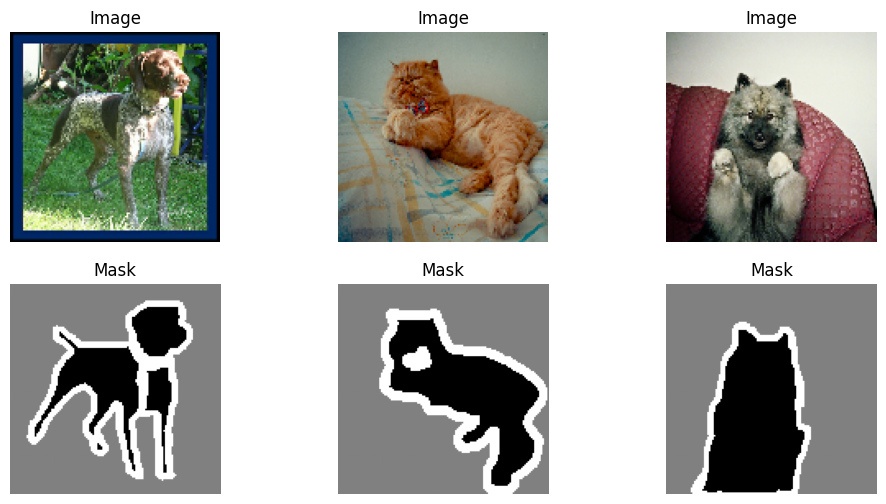

In [11]:
for images, masks in train_dataset.take(1):

    plt.figure(figsize = (12, 6))

    for i in range(3):

        plt.subplot(2, 3, i + 1)
        plt.imshow(images[i])
        plt.title("Image")
        plt.axis("off")

        plt.subplot(2, 3, i + 4)

        plt.imshow(
            masks[i, :, :, 0],
            cmap = "gray"
        )

        plt.title("Mask")
        plt.axis("off")

    plt.show()

## Encoder Block

In [12]:
def conv_block(inputs, filters):

    x = layers.Conv2D(filters, 3, padding = "same", use_bias = False)(inputs)
    x = layers.BatchNormalization(momentum = 0.9)(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding = "same", use_bias = False)(x)
    x = layers.BatchNormalization(momentum = 0.9)(x)
    x = layers.ReLU()(x)

    return x

In [13]:
def encoder_block(inputs, filters):

    features = conv_block(inputs, filters)
    pooled = layers.MaxPooling2D(pool_size = (2, 2))(features)

    return features, pooled

## Bottleneck

In [14]:
def bottleneck(inputs, filters):

    x = conv_block(inputs, filters)
    x = layers.Dropout(0.3)(x)

    return x

## Decoder Block

In [15]:
def decoder_block(inputs, skip_features, filters):

    x = layers.Conv2DTranspose(filters, 2, strides = 2, padding = "same")(inputs)
    x = layers.Concatenate()([x, skip_features])
    x = conv_block(x, filters)

    return x

## Building the U-Net

In [16]:
inputs = keras.Input(
    shape = (IMAGE_SIZE, IMAGE_SIZE, 3)
)

In [17]:
s1, p1 = encoder_block(inputs, 64)
s2, p2 = encoder_block(p1, 128)
s3, p3 = encoder_block(p2, 256)
s4, p4 = encoder_block(p3, 512)

In [18]:
bridge = bottleneck(p4, 1024)

In [19]:
d1 = decoder_block(bridge, s4, 512)
d2 = decoder_block(d1, s3, 256)
d3 = decoder_block(d2, s2, 128)
d4 = decoder_block(d3, s1, 64)

In [20]:
outputs = layers.Conv2D(
    NUM_CLASSES,
    1,
    activation="softmax"
)(d4)

## Creating the Model

In [21]:
unet_model = Model(
    inputs,
    outputs,
    name = "U-Net"
)

## Getting Model Summary

In [22]:
unet_model.summary()

Model: "U-Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │      1,728 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     36,864 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,728 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │    147,456 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │    294,912 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,049,539 (118.44 MB)

 Trainable params: 31,037,763 (118.40 MB)

 Non-trainable params: 11,776 (46.00 KB)

## Compiling the Model

In [23]:
unet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## Training the U-Net

In [24]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor = "val_loss",
        patience = 5,
        restore_best_weights = True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor = "val_loss",
        factor = 0.2,
        patience = 2
    )
]

In [25]:
history = unet_model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs = 20,
    callbacks = callbacks
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 167s 703ms/step - accuracy: 0.7224 - loss: 0.6668 - val_accuracy: 0.7340 - val_loss: 0.7024 - learning_rate: 0.0010
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 67s 583ms/step - accuracy: 0.7894 - loss: 0.5323 - val_accuracy: 0.8004 - val_loss: 0.5171 - learning_rate: 0.0010
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 72s 628ms/step - accuracy: 0.8200 - loss: 0.4611 - val_accuracy: 0.8085 - val_loss: 0.4927 - learning_rate: 0.0010
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 67s 588ms/step - accuracy: 0.8391 - loss: 0.4128 - val_accuracy: 0.8424 - val_loss: 0.4084 - learning_rate: 0.0010
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 67s 583ms/step - accuracy: 0.8552 - loss: 0.3733 - val_accuracy: 0.8564 - val_loss: 0.3743 - learning_rate: 0.0010
Epoch 6/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 67s 584ms/step - accuracy: 0.8636 - loss: 0.3508 - val_accuracy: 0.8565 - val_loss: 0.3732 - learning_rate: 0.0010
Epoch 7/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 67s 586ms/step - accuracy: 0.

## Evaluating the U-Net

In [26]:
loss, accuracy = unet_model.evaluate(
    test_dataset,
    verbose = 1
)

115/115 ━━━━━━━━━━━━━━━━━━━━ 16s 138ms/step - accuracy: 0.9023 - loss: 0.2663


In [27]:
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy:.4f}")

Test Loss     : 0.2663
Test Accuracy : 0.9023


## Predicting Segmentation Masks

In [28]:
def predict_mask(model, image):

    prediction = model.predict(
        tf.expand_dims(image, axis=0),
        verbose=0
    )

    prediction = tf.argmax(
        prediction,
        axis=-1
    )

    return prediction[0]

## Converting Probabilities into Masks

In [29]:
def create_mask(prediction):
    return tf.cast(
        prediction,
        tf.uint8
    )

## Visualising the Predictions

In [30]:
def display_predictions(image, true_mask, predicted_mask):

    plt.figure(figsize = (15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)

    plt.imshow(
        true_mask[:, :, 0],
        cmap = "gray"
    )

    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)

    plt.imshow(
        predicted_mask,
        cmap="gray"
    )

    plt.title("Prediction")
    plt.axis("off")
    plt.tight_layout()

    plt.show()

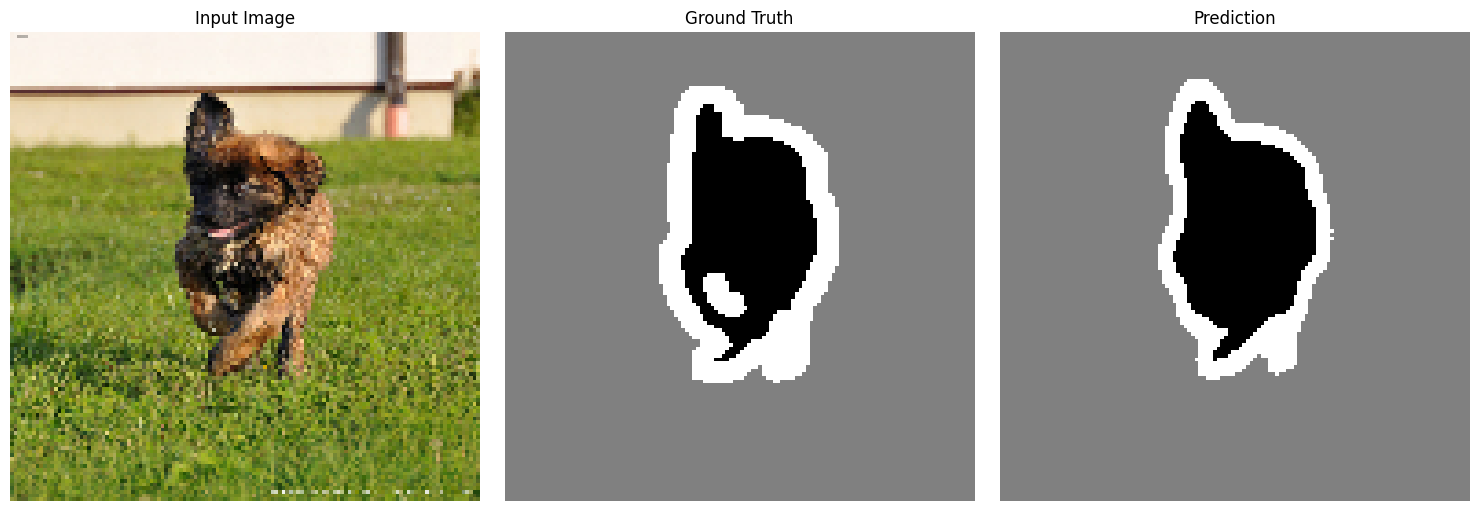

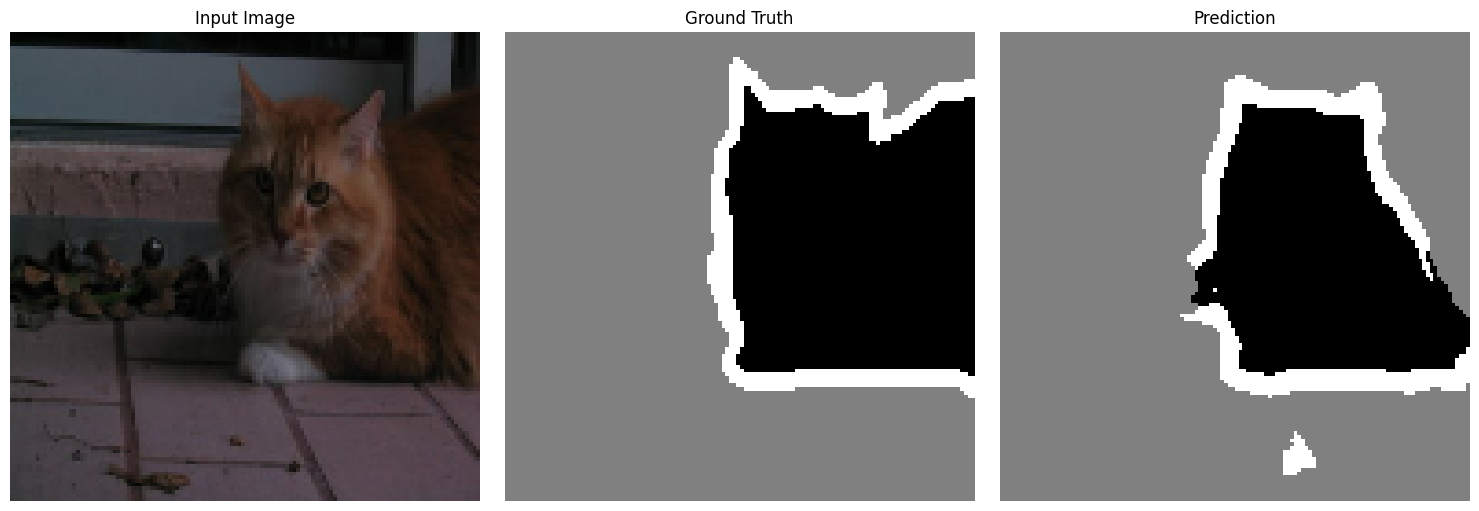

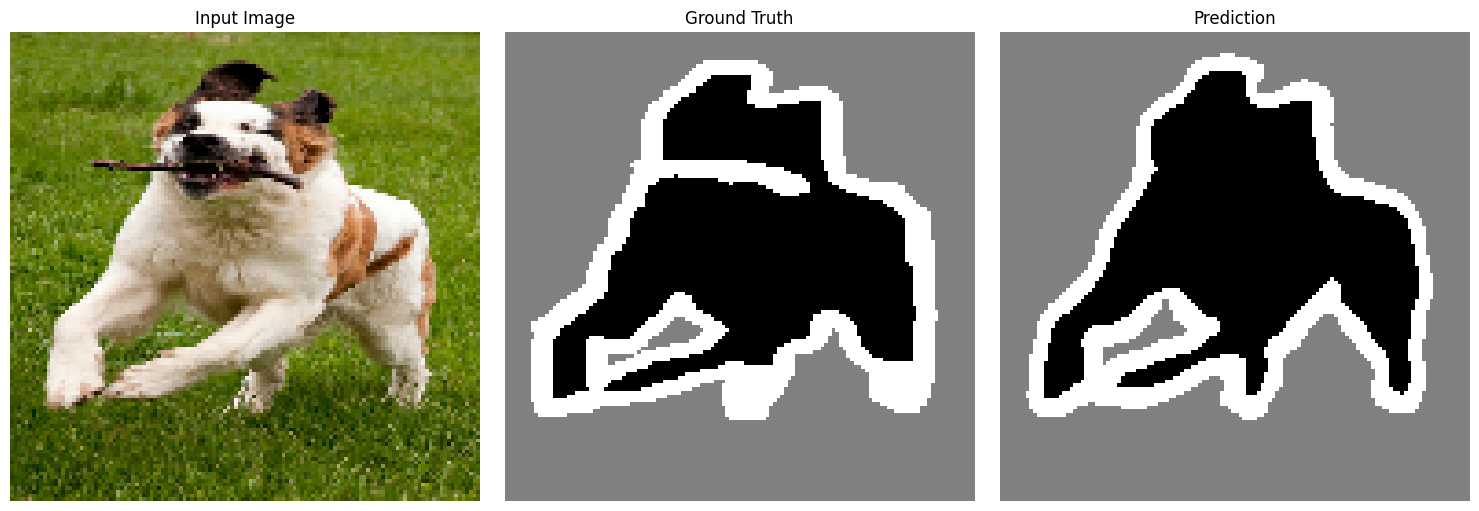

In [31]:
for images, masks in test_dataset.take(1):

    for i in range(3):

        prediction = predict_mask(
            unet_model,
            images[i]
        )

        display_predictions(
            images[i],
            masks[i],
            prediction
        )

## Saving the U-Net

In [32]:
unet_model.save(
    "unet_segmentation.keras"
)

## Loading the Saved Model

In [33]:
unet_model = keras.models.load_model(
    "unet_segmentation.keras"
)

## Semantic Segmentation using DeepLabV3+

### Loading the pretrained DeepLabV3+

In [ ]:
!pip install keras-hub

In [35]:
import keras_hub

In [ ]:
deeplab_model = keras_hub.models.DeepLabV3ImageSegmenter.from_preset(
    "deeplab_v3_plus_resnet50_pascalvoc"
)

### Loading a VOC Image

In [37]:
sample = next(
    iter(voc_dataset["test"])
)

image = tf.cast(
    sample["image"],
    tf.float32
)

display_image = image / 255.0

### Predicting the Semantic Mask

In [38]:
image = tf.image.resize(image, (512, 512))

prediction = deeplab_model.predict(
    tf.expand_dims(image, 0),
    verbose = 0
)

prediction = np.argmax(
    prediction,
    axis = -1
)

### Visualising the Prediction

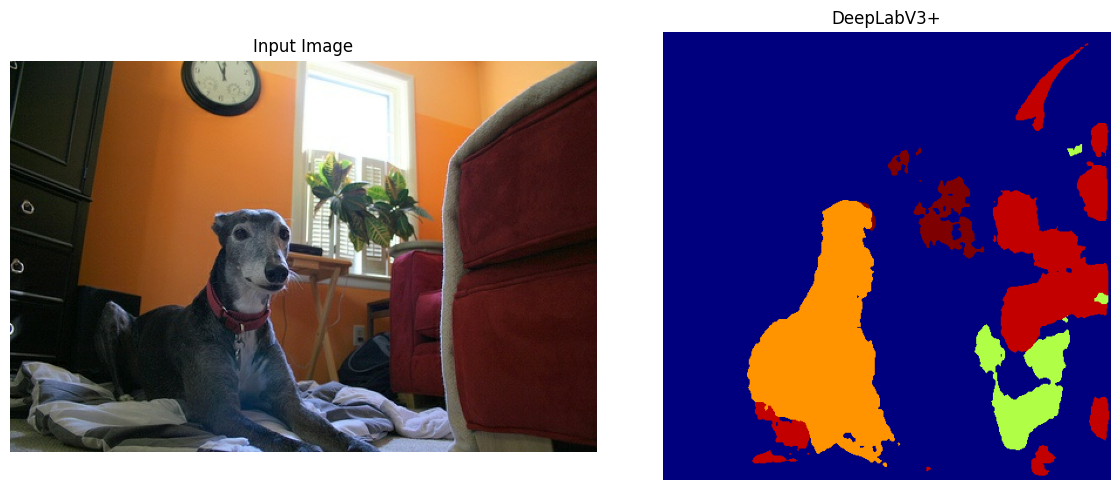

In [39]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.imshow(display_image)

plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)

plt.imshow(
    prediction[0],
    cmap = "jet"
)

plt.title("DeepLabV3+")
plt.axis("off")
plt.tight_layout()

plt.show()

### Predicting Multiple Images

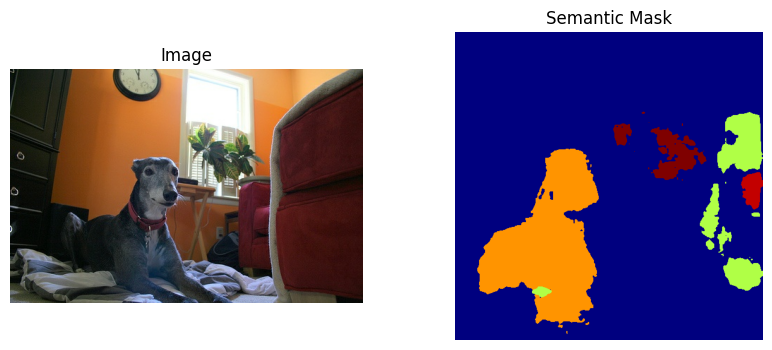

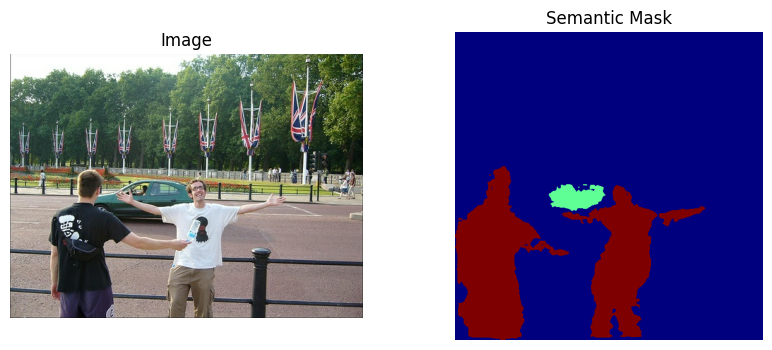

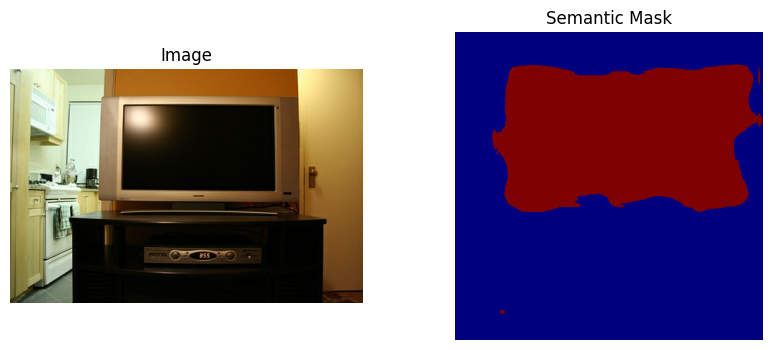

In [40]:
for sample in voc_dataset["test"].take(3):

    image = tf.cast(
        sample["image"],
        tf.float32
    )

    prediction = deeplab_model.predict(
        tf.expand_dims(image,0),
        verbose=0
    )

    prediction = np.argmax(
        prediction,
        axis=-1
    )

    plt.figure(figsize = (10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image / 255.)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(
        prediction[0],
        cmap = "jet"
    )

    plt.title("Semantic Mask")
    plt.axis("off")
    plt.show()

## Instance Segmentation using Mask R-CNN

### Importing the Libraries

In [41]:
import cv2
import torch
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.transforms.functional import to_tensor

### Loading the pretrained Mask R-CNN

In [ ]:
maskrcnn_model = maskrcnn_resnet50_fpn(
    weights = "DEFAULT"
)

maskrcnn_model.eval();

### Loading an Image

In [44]:
image = cv2.imread(
    "image.jpg"
)

image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

tensor = to_tensor(image)

### Predicting the Objects

In [45]:
with torch.no_grad():
    output = maskrcnn_model(
        [tensor]
    )[0]

### Printing the Detected Objects

In [46]:
print(output["labels"])

tensor([17, 15, 67, 15, 67, 17, 65, 63, 15, 65])


### Printing the Bounding Boxes

In [47]:
print(output["boxes"])

tensor([[ 725.1422,  179.6691, 3641.4470, 3268.0466],
        [ 258.5669, 2635.6641, 5020.5044, 3418.3501],
        [ 242.4318, 2767.4829, 5026.0000, 3372.9622],
        [  58.9473, 1371.2551, 4849.3809, 3397.8809],
        [ 929.6774, 2318.9802, 5026.0000, 3436.0183],
        [3023.0032, 2391.8567, 3666.1802, 3212.1482],
        [ 174.5154, 2637.4011, 4198.5498, 3415.8206],
        [  21.2448, 2654.2041, 5026.0000, 3406.4182],
        [  23.9037, 2675.9675, 1596.3350, 3420.2427],
        [  77.5281, 1494.6544, 4763.6211, 3396.2468]])


### Printing the Instance Masks

In [48]:
print(output["masks"].shape)

torch.Size([10, 1, 3458, 5026])


### Visualising the Instance maskM

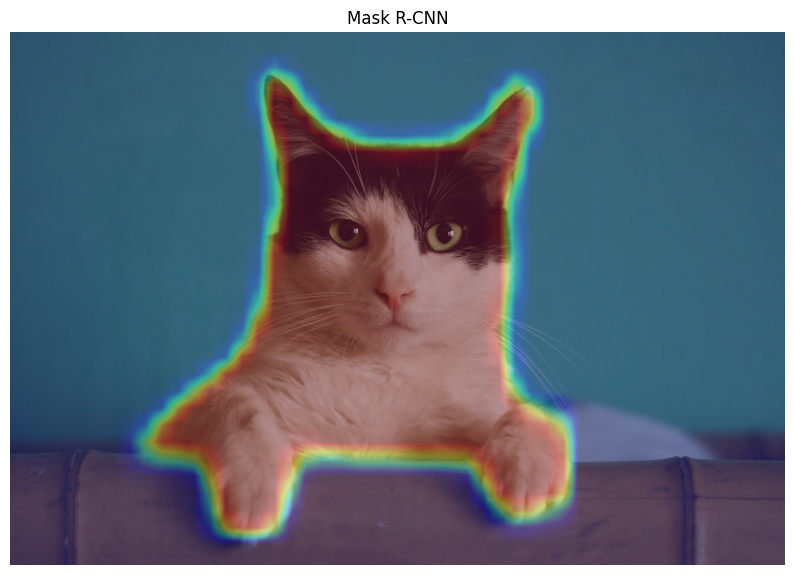

In [49]:
plt.figure(figsize = (10, 10))
plt.imshow(image)

for mask, score in zip(output["masks"], output["scores"]):

    if score > 0.5:
        plt.imshow(mask[0], alpha = 0.35, cmap = "jet")

plt.axis("off")
plt.title("Mask R-CNN")
plt.show()

## U-Net++

>**U-Net++** is an improved version of **U-Net** that introduces nested and >dense skip
>connections between the encoder and decoder. These redesigned skip pathways
>reduce the semantic gap between encoder and decoder feature maps, leading to
>more accurate segmentation, especially for medical imaging tasks.
>
><br/>
>
>Unlike the original U-Net, U-Net++ employs multiple intermediate convolution
>blocks before feature fusion, allowing the decoder to recover finer spatial
>details.
>
><br/>
>
>Although the architecture is more computationally expensive than U-Net, it
>typically achieves higher segmentation accuracy on complex datasets.

### U-Net++ Block

In [50]:
def unetpp_block(inputs, filters):

    x = layers.Conv2D(filters, 3, padding = "same", use_bias = False)(inputs)
    x = layers.BatchNormalization(momentum = 0.9)(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding = "same", use_bias = False)(x)
    x = layers.BatchNormalization(momentum = 0.9)(x)
    x = layers.ReLU()(x)

    return x

### Building the U-Net++

#### Input Layer

In [51]:
inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3))

##### Encoder Block

In [52]:
x00 = conv_block(inputs, 64)
p0 = layers.MaxPooling2D()(x00)

x10 = conv_block(p0, 128)
p1 = layers.MaxPooling2D()(x10)

x20 = conv_block(p1, 256)
p2 = layers.MaxPooling2D()(x20)

x30 = conv_block(p2, 512)
p3 = layers.MaxPooling2D()(x30)

x40 = conv_block(p3, 1024)

##### Decoder Block

In [53]:
# X0,1
x01 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(x10)
x01 = layers.Concatenate()([x00, x01])
x01 = conv_block(x01, 64)

# X1,1
x11 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(x20)
x11 = layers.Concatenate()([x10, x11])
x11 = conv_block(x11, 128)

# X2,1
x21 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(x30)
x21 = layers.Concatenate()([x20, x21])
x21 = conv_block(x21, 256)

# X3,1
x31 = layers.Conv2DTranspose(512, 2, strides=2, padding="same")(x40)
x31 = layers.Concatenate()([x30, x31])
x31 = conv_block(x31, 512)

# X0,2
x02 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(x11)
x02 = layers.Concatenate()([x00, x01, x02])
x02 = conv_block(x02, 64)

# X1,2
x12 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(x21)
x12 = layers.Concatenate()([x10, x11, x12])
x12 = conv_block(x12, 128)

# X2,2
x22 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(x31)
x22 = layers.Concatenate()([x20, x21, x22])
x22 = conv_block(x22, 256)

# X0,3
x03 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(x12)
x03 = layers.Concatenate()([x00, x01, x02, x03])
x03 = conv_block(x03, 64)

# X1,3
x13 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(x22)
x13 = layers.Concatenate()([x10, x11, x12, x13])
x13 = conv_block(x13, 128)

# X0,4
x04 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(x13)
x04 = layers.Concatenate()([x00, x01, x02, x03, x04])
x04 = conv_block(x04, 64)

In [54]:
outputs = layers.Conv2D(
    NUM_CLASSES,
    1,
    activation="softmax"
)(x04)

## Creating the model

In [55]:
unetpp_model = keras.Model(
    inputs,
    outputs,
    name = "UNetPP"
)

### Getting Model Summary

In [56]:
unetpp_model.summary()

Model: "UNetPP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 128, 128,  │      1,728 │ input_layer_8[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_18 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 128, 128,  │     36,864 │ re_lu_18[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_19 (ReLU)     │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 64, 64,    │          0 │ re_lu_19[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 64, 64,    │     73,728 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_21[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_20 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 64, 64,    │    147,456 │ re_lu_20[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_22[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_21 (ReLU)     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 32, 32,    │          0 │ re_lu_21[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 32, 32,    │    294,912 │ max_pooling2d_5[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │      1,024 │ conv2d_23[0][0] 

 Total params: 36,179,971 (138.02 MB)

 Trainable params: 36,165,379 (137.96 MB)

 Non-trainable params: 14,592 (57.00 KB)

### Compiling the Model

In [57]:
unetpp_model.compile(
    optimizer = keras.optimizers.Adam(1e-4),
    loss = "sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Training the U-Net++

In [58]:
history = unetpp_model.fit(
    train_dataset,
    validation_data = test_dataset,
    epochs = 20,
    callbacks = callbacks
)

Epoch 1/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.7082 - loss: 0.7006 - val_accuracy: 0.7936 - val_loss: 0.5323 - learning_rate: 1.0000e-04
Epoch 2/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8114 - loss: 0.4868 - val_accuracy: 0.7928 - val_loss: 0.5342 - learning_rate: 1.0000e-04
Epoch 3/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.8491 - loss: 0.3942 - val_accuracy: 0.8489 - val_loss: 0.3920 - learning_rate: 2.0000e-05
Epoch 4/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.8607 - loss: 0.3642 - val_accuracy: 0.8522 - val_loss: 0.3866 - learning_rate: 2.0000e-05
Epoch 5/20
115/115 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8741 - loss: 0.3316 - val_accuracy: 0.8572 - val_loss: 0.3744 - learning_rate: 4.0000e-06


### Evaluating the U-Net++

In [59]:
loss, accuracy = unetpp_model.evaluate(
    test_dataset
)

115/115 ━━━━━━━━━━━━━━━━━━━━ 41s 352ms/step - accuracy: 0.7936 - loss: 0.5323


In [60]:
print("Loss     :", loss)
print("Accuracy :", accuracy)

Loss     : 0.5322932600975037
Accuracy : 0.7935909032821655


### Predicting test set

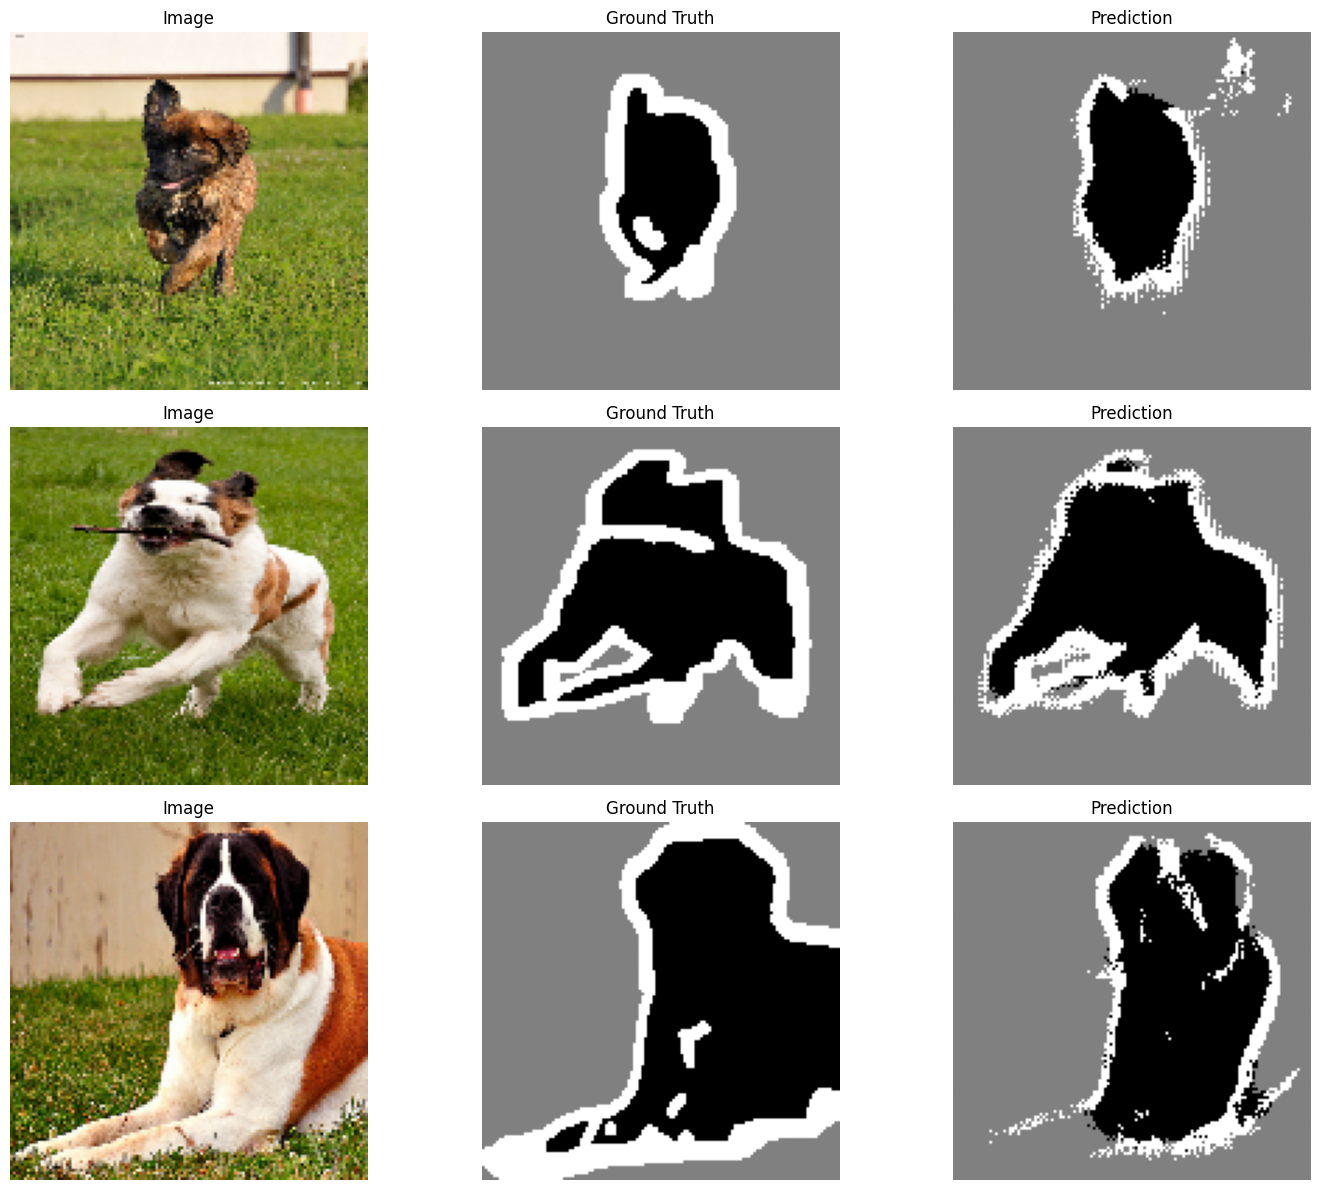

In [79]:
for images, masks in test_dataset.take(1):

    prediction = unetpp_model.predict(
        images,
        verbose=0
    )

    prediction = np.argmax(
        prediction,
        axis=-1
    )

    plt.figure(figsize = (15, 12))

    for j, i in enumerate([0, 2, 3]):

        plt.subplot(3, 3, 3 * j + 1)
        plt.imshow(images[i])
        plt.title("Image")
        plt.axis("off")

        plt.subplot(3, 3, 3 * j + 2)
        plt.imshow(
            masks[i, :, :, 0],
            cmap="gray"
        )
        plt.title("Ground Truth")
        plt.axis("off")

        plt.subplot(3, 3, 3 * j + 3)
        plt.imshow(
            prediction[i],
            cmap="gray"
        )
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## Comparison of Segmentation Models

| Model      | Type     | Framework   | Pretrained | Dataset         |
| ---------- | -------- | ----------- | ---------- | --------------- |
| U-Net      | Semantic | TensorFlow  | No         | Oxford-IIIT Pet |
| U-Net++    | Semantic | TensorFlow  | No         | Oxford-IIIT Pet |
| DeepLabV3+ | Semantic | KerasHub    | Yes        | Pascal VOC      |
| Mask R-CNN | Instance | TorchVision | Yes        | COCO            |


## Predicting a New Image using U-Net

In [62]:
from keras.utils import load_img
from keras.utils import img_to_array

In [63]:
def predict_image(model, image_path):

    image = load_img(image_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))

    image = img_to_array(image)
    image = image / 255.

    prediction = model.predict(
        np.expand_dims(image,0),
        verbose = 0
    )

    prediction = np.argmax(
        prediction,
        axis = -1
    )

    plt.figure(figsize = (12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)

    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)

    plt.imshow(
        prediction[0],
        cmap = "gray"
    )

    plt.title("Predicted Mask")
    plt.axis("off")
    plt.tight_layout()

    plt.show()

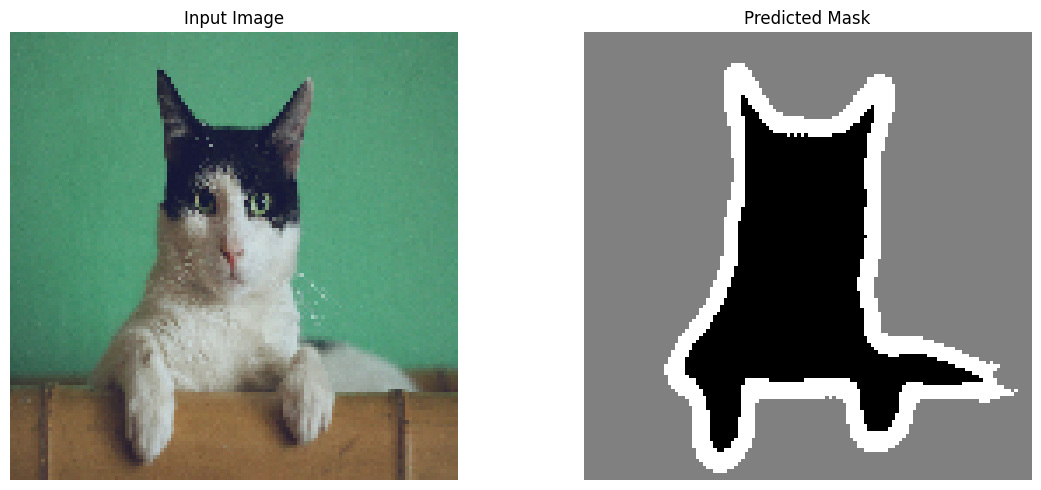

In [64]:
predict_image(
    unet_model,
    "image.jpg"
)